Stopped at epoch 242


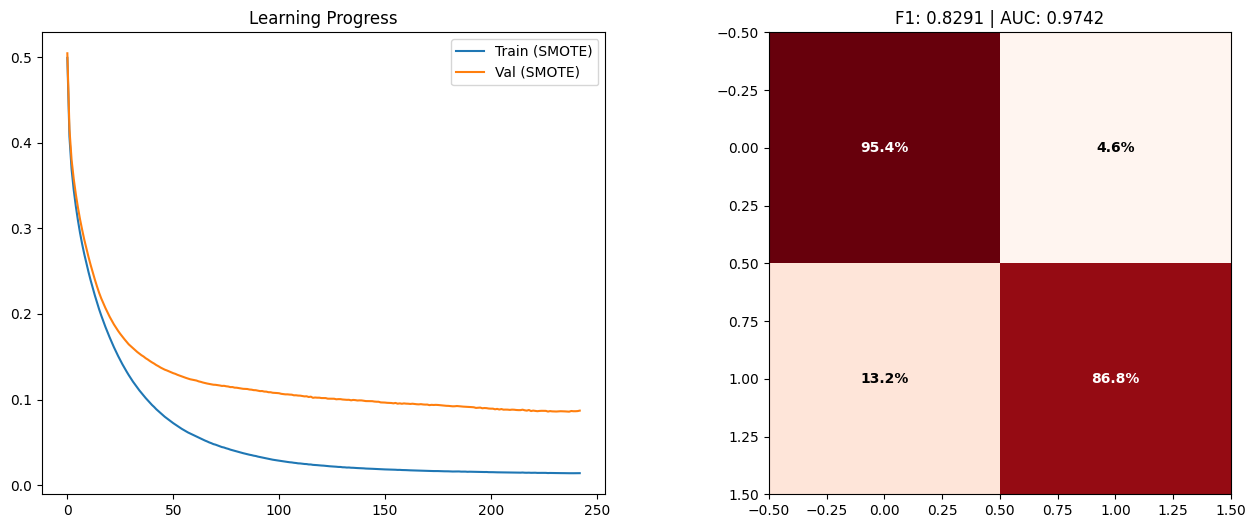

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, log_loss
from src.seed import set_seed
from sklearn import set_config
from src.pipeline.missing_value import CJ_MissingValue, JH_MissingValue, JH_train_stats
from src.pipeline.outlier_control import OutlierControl
from src.pipeline.features import FeatureCreate

# 0. 환경 설정
set_seed(42)
set_config(transform_output="pandas") 
warnings.filterwarnings("ignore")

# 1. 데이터 로드 및 초기 정제
data = pd.read_excel("../../data/dataset.xlsx").drop_duplicates(subset=["CustomerID"], keep="first")

# [Leakage 방지] 전처리 전 제거
drop_cols = ["CustomerID", "IssueIndex", "Dormancy_Shock", "Silent_Killer", "Recency_Tenure_Ratio", "Stagnant_Loyal"]
data.drop(columns=drop_cols, inplace=True, errors="ignore")

X = data.drop("Churn", axis=1)
y = data["Churn"]

# 2. 데이터 분할 (전처리 전 분할 필수)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. 전처리 파이프라인 실행 (함수들이 정의되어 있다는 전제)
# A. 결측치 처리
CJ_SPECS = (
    ("Tenure", "NumberOfAddress", 5),
    ("DaySinceLastOrder", ["PreferedOrderCat", "PreferredLoginDevice"], 10),
    ("OrderCount", ["PreferedOrderCat", "PreferredPaymentMode"], 10),
    ("OrderAmountHikeFromlastYear", "PreferedOrderCat", 3),
)
for col, gps, mgs in CJ_SPECS:
    CJ_MissingValue(X_train, col, gps, mgs, X_train[col].median(), X_test)

jh_stats = JH_train_stats(X_train)
for df in [X_train, X_test]:
    JH_MissingValue(df, **jh_stats)

# B. 이상치 및 피처 생성
OutlierControl(X_train, ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder', 'CashbackAmount'])
OutlierControl(X_test, ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder', 'CashbackAmount'])

X_train = FeatureCreate(X_train)
X_test = FeatureCreate(X_test, train_monthly_freq_mean=X_train['MonthlyOrderFreq'].mean())
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 4. 스케일링 (모든 전처리가 끝난 데이터프레임 사용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. SMOTE 적용 (학습셋 스케일링 완료 후 적용)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

# 6. 모델 및 학습 설정 
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.2,               
    learning_rate_init=0.001,
    max_iter=1, 
    warm_start=True,
    random_state=42
)

# 7. 검증용 분할 및 에폭 학습
X_tr, X_val, y_tr, y_val = train_test_split(X_res, y_res, test_size=0.2, stratify=y_res)
train_losses, val_losses = [], []

for epoch in range(1000):
    mlp.partial_fit(X_tr, y_tr, classes=np.unique(y_res))
    
    tr_loss = log_loss(y_tr, mlp.predict_proba(X_tr))
    va_loss = log_loss(y_val, mlp.predict_proba(X_val))
    
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    
    # Early Stopping: 20 에폭 동안 개선 없으면 중단
    if len(val_losses) > 20 and val_losses[-1] > min(val_losses[:-20]):
        print(f"Stopped at epoch {epoch}")
        break

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Loss 곡선
ax1.plot(train_losses, label="Train (SMOTE)")
ax1.plot(val_losses, label="Val (SMOTE)")
ax1.set_title("Learning Progress")
ax1.legend()

# 혼동 행렬
y_prob = mlp.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int) 
cm = confusion_matrix(y_test, y_pred, normalize="true")

ax2.imshow(cm, cmap="Reds")
ax2.set_title(f"F1: {f1_score(y_test, y_pred):.4f} | AUC: {roc_auc_score(y_test, y_prob):.4f}")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{cm[i, j]*100:.1f}%", ha="center", va="center", 
                color="white" if cm[i, j] > 0.5 else "black", weight='bold')
plt.show()